In [ ]:
# data for next word prediction model
documents = """Artificial intelligence is changing the way people live and work.
Machine learning allows computers to learn from data without being explicitly programmed.
Deep learning is a subset of machine learning that uses neural networks.
Neural networks consist of layers of interconnected neurons.
Data is the fuel that powers machine learning algorithms.
The quality of data greatly affects the performance of a model.
A well trained model can make accurate predictions.
Training a neural network requires patience and computational resources.
Optimization algorithms help reduce the loss during training.
Gradient descent is one of the most popular optimization techniques.
Python is one of the most popular programming languages.
Python has a simple syntax that is easy to understand.
Developers use Python for web development and data science.
Python also supports machine learning and deep learning.
Libraries such as NumPy and Pandas simplify data analysis.
Matplotlib is commonly used for data visualization.
PyTorch and TensorFlow are powerful deep learning frameworks.
Writing clean code improves readability and maintainability.
Functions help organize reusable pieces of code.
Classes allow developers to create reusable objects.
Natural language processing enables computers to understand human language.
Text preprocessing includes tokenization and lowercasing.
Stop words are often removed during preprocessing.
Stemming reduces words to their root form.
Lemmatization converts words into meaningful base words.
Word embeddings capture semantic relationships between words.
Recurrent neural networks process sequential information.
Long short term memory networks solve the vanishing gradient problem.
Transformers have become the standard architecture for language models.
Attention mechanisms help models focus on important words.
A student studies every day to improve knowledge.
Consistent practice leads to better understanding.
Hard work combined with smart work produces excellent results.
Reading books expands knowledge and vocabulary.
Solving problems improves logical thinking.
Curiosity drives innovation and creativity.
Learning never truly ends.
Every mistake provides an opportunity to learn.
Discipline is more important than motivation.
Success comes from continuous improvement.
The weather was pleasant in the morning.
Birds were singing on the trees.
Children were playing in the park.
People enjoyed walking in the fresh air.
The sun slowly rose above the mountains.
Clouds moved gently across the blue sky.
Rain refreshed the dry land.
Farmers welcomed the rainfall.
Nature provides beauty and peace.
Every season has its own charm.
Software engineering involves designing reliable systems.
Version control helps developers track code changes.
Git is widely used for source code management.
Repositories store project files and history.
Branches allow parallel development.
Developers merge branches after completing features.
Testing ensures software behaves correctly.
Debugging helps identify and fix issues.
Documentation makes projects easier to understand.
Continuous integration automates testing and deployment.
Computer vision enables machines to understand images.
Images are represented as matrices of pixels.
Convolutional neural networks extract image features.
Pooling layers reduce spatial dimensions.
Feature maps capture visual patterns.
Object detection identifies multiple objects in an image.
Image segmentation labels every pixel.
Transfer learning speeds up model training.
Data augmentation improves generalization.
Accurate datasets improve computer vision models.
A researcher asks meaningful questions.
Experiments validate scientific hypotheses.
Observations lead to new discoveries.
Knowledge grows through continuous research.
Innovation solves real world problems.
Technology advances society.
Engineers transform ideas into reality.
Scientists explore the unknown.
Mathematics forms the foundation of engineering.
Physics explains the laws of nature.
Books inspire imagination and creativity.
Reading every day develops strong communication skills.
Stories teach valuable life lessons.
Authors express ideas through words.
Readers connect with different characters.
Libraries preserve knowledge for future generations.
Education empowers individuals.
Knowledge creates opportunities.
Wisdom comes through experience.
Learning is a lifelong journey.
Morning exercise improves physical health.
Healthy food provides essential nutrients.
Drinking enough water keeps the body hydrated.
Regular sleep improves concentration.
Meditation reduces stress and anxiety.
Good habits create a better future.
Small daily improvements lead to remarkable results.
A positive mindset encourages resilience.
Discipline builds confidence.
Healthy living increases productivity.
Artificial intelligence continues to evolve rapidly.
Researchers develop better algorithms every year.
Large language models understand complex text.
Generative models create realistic images and text.
Ethical AI promotes fairness and transparency.
Responsible development benefits society.
Collaboration accelerates innovation.
Knowledge sharing strengthens communities.
Future technologies will transform industries.
Continuous learning prepares people for the future."""

In [ ]:
import string
import numpy as np
import torch
import torch.nn
import nltk
import torch.optim as optim

from torch import nn
from nltk.tokenize import word_tokenize
from torch.utils.data import Dataset, DataLoader
from collections import Counter

## Preprocessing data in raw to embedded form

In [ ]:
# tokeinze words
nltk.download("punkt")
nltk.download("punkt_tab")
tokens = word_tokenize(documents)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
tokens

['Artificial',
 'intelligence',
 'is',
 'changing',
 'the',
 'way',
 'people',
 'live',
 'and',
 'work',
 '.',
 'Machine',
 'learning',
 'allows',
 'computers',
 'to',
 'learn',
 'from',
 'data',
 'without',
 'being',
 'explicitly',
 'programmed',
 '.',
 'Deep',
 'learning',
 'is',
 'a',
 'subset',
 'of',
 'machine',
 'learning',
 'that',
 'uses',
 'neural',
 'networks',
 '.',
 'Neural',
 'networks',
 'consist',
 'of',
 'layers',
 'of',
 'interconnected',
 'neurons',
 '.',
 'Data',
 'is',
 'the',
 'fuel',
 'that',
 'powers',
 'machine',
 'learning',
 'algorithms',
 '.',
 'The',
 'quality',
 'of',
 'data',
 'greatly',
 'affects',
 'the',
 'performance',
 'of',
 'a',
 'model',
 '.',
 'A',
 'well',
 'trained',
 'model',
 'can',
 'make',
 'accurate',
 'predictions',
 '.',
 'Training',
 'a',
 'neural',
 'network',
 'requires',
 'patience',
 'and',
 'computational',
 'resources',
 '.',
 'Optimization',
 'algorithms',
 'help',
 'reduce',
 'the',
 'loss',
 'during',
 'training',
 '.',
 'Gradie

In [ ]:
# build vocabulary
vocab = {'<UNK>': 0}

for word in Counter(tokens).keys():
  if word not in vocab:
    vocab[word] = len(vocab)

In [ ]:
len(vocab)

472

In [ ]:
# generate sentences by new lines
sentence = documents.split('\n')

In [ ]:
len(sentence), sentence[-1]

(110, 'Continuous learning prepares people for the future.')

In [ ]:
# function to generate sequence from sentence
def text_to_seq(text, vocab):
  seq_sentence = []

  for token in text:
    if token in vocab:
      seq_sentence.append(vocab[token])
    else:
      seq_sentence.append(vocab['<UNK>'])

  return seq_sentence


In [ ]:
num_sentences = []

for sent in sentence:
  num_sentences.append(text_to_seq(word_tokenize(sent), vocab))


In [ ]:
len(num_sentences)

110

In [ ]:
train_seq = []
for sentence in num_sentences:
  for i in range(1, len(sentence)):
    train_seq.append(sentence[:i + 1])


In [ ]:
len(train_seq)

695

In [ ]:
# taking longest sentence length for padding
padding = len(max(train_seq, key=lambda x:len(x)))

In [ ]:
# adding padding on every sequence of sentence
padded_train_seq = []
for sequence in train_seq:
  padded_train_seq.append([0] * (padding - len(sequence)) + sequence)

In [ ]:
len(padded_train_seq[522])

13

In [ ]:
# training data in tensor
training_seq_tensor = torch.tensor(padded_train_seq, dtype=torch.long)
training_seq_tensor.shape

torch.Size([695, 13])

In [ ]:
# features - every sentence of seq except last word(it will be predicted).
X = training_seq_tensor[:, :-1]
y = training_seq_tensor[:, -1]

In [ ]:
X.shape

torch.Size([695, 12])

## Create dataset

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, x, y):
    self.X = x
    self.y = y

  def __len__(self):
    return self.X.shape[0]
  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [ ]:
dataset = CustomDataset(X, y)
len(dataset)

695

In [ ]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [ ]:
for sent, output in loader:
  example, output = sent, output
  break

## create LSTM model

In [ ]:
class LSTMModel(nn.Module):

  def __init__(self, vocab_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, 100)
    self.model = nn.LSTM(100, 150, batch_first=True)
    self.layer = nn.Linear(150, vocab_size)

  def forward(self, x):
    embedded = self.embedding(x)
    inter_hidded_state, (final_hidden_state, final_cell_state) = self.model(embedded)
    output = self.layer(final_hidden_state.squeeze(0))
    return output


In [ ]:
# configure gpu to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = LSTMModel(len(vocab))
model.to(device)

LSTMModel(
  (embedding): Embedding(472, 100)
  (model): LSTM(100, 150, batch_first=True)
  (layer): Linear(in_features=150, out_features=472, bias=True)
)

In [ ]:
# init dependencies
epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# training loop
loss_graph = []
for e in range(epochs):
  total_loss = 0

  for features, labels in loader:
    batch_x, batch_y = features.to(device), labels.to(device)
    optimizer.zero_grad()

    # prediction
    output = model(batch_x)

    # loss calculation
    loss = criterion(output, batch_y)

    # weights update
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  loss_graph.append(total_loss)
  print(f"Epochs: {e + 1}/{epochs}, Loss: {total_loss}")

Epochs: 1/50, Loss: 134.96832036972046
Epochs: 2/50, Loss: 120.95053291320801
Epochs: 3/50, Loss: 110.33094692230225
Epochs: 4/50, Loss: 104.66371583938599
Epochs: 5/50, Loss: 100.31727266311646
Epochs: 6/50, Loss: 94.85978674888611
Epochs: 7/50, Loss: 89.2237651348114
Epochs: 8/50, Loss: 83.11602115631104
Epochs: 9/50, Loss: 77.48011112213135
Epochs: 10/50, Loss: 71.2856674194336
Epochs: 11/50, Loss: 65.35681414604187
Epochs: 12/50, Loss: 59.23267841339111
Epochs: 13/50, Loss: 53.444236755371094
Epochs: 14/50, Loss: 47.723854064941406
Epochs: 15/50, Loss: 42.45001792907715
Epochs: 16/50, Loss: 37.43039560317993
Epochs: 17/50, Loss: 32.8294278383255
Epochs: 18/50, Loss: 28.6384379863739
Epochs: 19/50, Loss: 24.840497732162476
Epochs: 20/50, Loss: 21.498822510242462
Epochs: 21/50, Loss: 18.74092000722885
Epochs: 22/50, Loss: 16.163269519805908
Epochs: 23/50, Loss: 14.148832857608795
Epochs: 24/50, Loss: 12.341279298067093
Epochs: 25/50, Loss: 10.89103776216507
Epochs: 26/50, Loss: 9.639

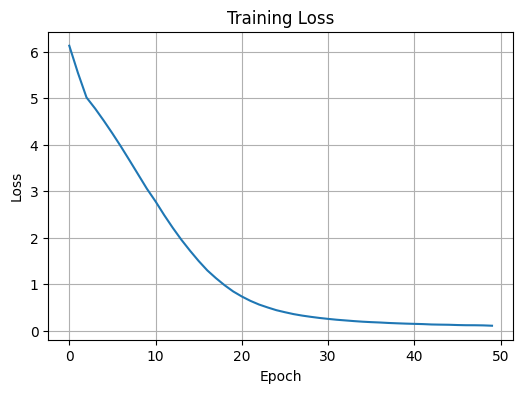

In [ ]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(6,4))
plt.plot(loss_graph)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Prediction function

In [ ]:
def pred(model, vocab, text):
  # tokenize text
  tokenized_text = word_tokenize(text)

  # text -> indicies
  sequences = text_to_seq(tokenized_text, vocab)

  # padding
  padded_text = torch.tensor([0] * (12 - len(sequences)) + sequences, dtype=torch.long).unsqueeze(0)

  # send to model
  padded_text = padded_text.to(device)
  output = model(padded_text)

  # prediction
  value, index = torch.max(output, dim=1)

  # merge with text
  return text + " " + list(vocab.keys())[index]

In [ ]:
pred(model, vocab, "Training a neural network requires")

'Training a neural network requires patience'